# 第32章: シミュレーション

## 学習目標
- 擬似乱数生成を理解する
- 逆変換法を適用できる
- 棄却法を実装できる
- モンテカルロ積分を実行できる
- ブートストラップ法を適用できる
- MCMCの基礎を理解する

## 📋 学習メタ情報

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_func
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 32.1 擬似乱数生成

### 線形合同法
$$X_{n+1} = (aX_n + c) \mod m$$

### 一様乱数からの変換
他の分布の乱数を生成する基礎

### 品質の検定
- 周期性
- 独立性
- 一様性

擬似乱数生成

LCG乱数の基本統計量:
  平均: 0.5082 (理論値: 0.5)
  分散: 0.0850 (理論値: 0.0833)


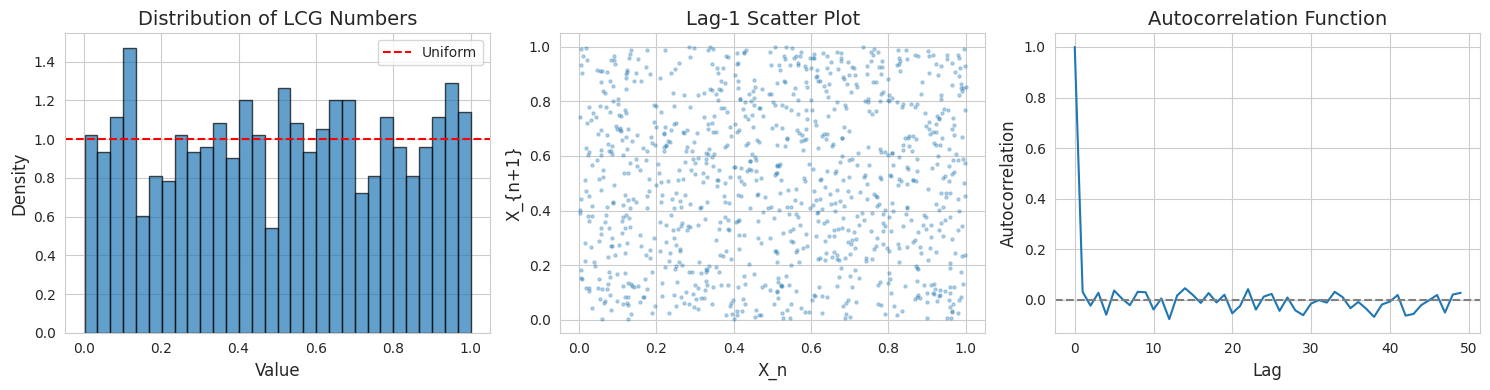

In [2]:
# 線形合同法の実装
def linear_congruential_generator(n, seed=1, a=1103515245, c=12345, m=2**31):
    """Simple LCG for pseudo-random number generation."""
    x = seed
    random_numbers = []
    for _ in range(n):
        x = (a * x + c) % m
        random_numbers.append(x / m)
    return np.array(random_numbers)

# Generate random numbers
n = 1000
lcg_numbers = linear_congruential_generator(n, seed=42)

print("擬似乱数生成")
print("="*60)

# Compare with numpy
numpy_numbers = np.random.rand(n)

print(f"\nLCG乱数の基本統計量:")
print(f"  平均: {np.mean(lcg_numbers):.4f} (理論値: 0.5)")
print(f"  分散: {np.var(lcg_numbers):.4f} (理論値: {1/12:.4f})")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(lcg_numbers, bins=30, density=True, alpha=0.7, edgecolor='black')
axes[0].axhline(1, color='red', linestyle='--', label='Uniform')
axes[0].set_xlabel('Value', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of LCG Numbers', fontsize=14)
axes[0].legend()

# Scatter plot (lag-1)
axes[1].scatter(lcg_numbers[:-1], lcg_numbers[1:], alpha=0.3, s=5)
axes[1].set_xlabel('X_n', fontsize=12)
axes[1].set_ylabel('X_{n+1}', fontsize=12)
axes[1].set_title('Lag-1 Scatter Plot', fontsize=14)

# Autocorrelation
from scipy.signal import correlate
autocorr = np.correlate(lcg_numbers - np.mean(lcg_numbers), 
                        lcg_numbers - np.mean(lcg_numbers), mode='full')
autocorr = autocorr[len(autocorr)//2:] / autocorr[len(autocorr)//2]
axes[2].plot(autocorr[:50])
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('Lag', fontsize=12)
axes[2].set_ylabel('Autocorrelation', fontsize=12)
axes[2].set_title('Autocorrelation Function', fontsize=14)

plt.tight_layout()
plt.show()

## 32.2 逆変換法

### 原理
累積分布関数 $F(x)$ の逆関数を使用

$$X = F^{-1}(U), \quad U \sim \text{Uniform}(0, 1)$$

### 証明
$$P(X \leq x) = P(F^{-1}(U) \leq x) = P(U \leq F(x)) = F(x)$$

In [3]:
# 逆変換法
print("逆変換法")
print("="*60)

# Example 1: Exponential distribution
# F(x) = 1 - exp(-λx), F^{-1}(u) = -ln(1-u)/λ

def inverse_transform_exponential(n, lam=1):
    """Generate exponential random variables using inverse transform."""
    u = np.random.rand(n)
    return -np.log(1 - u) / lam

n = 10000
lam = 2
samples_exp = inverse_transform_exponential(n, lam)

print(f"\n指数分布 (λ = {lam}):")
print(f"  標本平均: {np.mean(samples_exp):.4f} (理論値: {1/lam:.4f})")
print(f"  標本分散: {np.var(samples_exp):.4f} (理論値: {1/lam**2:.4f})")

# Example 2: Cauchy distribution
# F^{-1}(u) = tan(π(u - 0.5))

def inverse_transform_cauchy(n):
    """Generate Cauchy random variables using inverse transform."""
    u = np.random.rand(n)
    return np.tan(np.pi * (u - 0.5))

samples_cauchy = inverse_transform_cauchy(n)

逆変換法

指数分布 (λ = 2):
  標本平均: 0.4901 (理論値: 0.5000)
  標本分散: 0.2367 (理論値: 0.2500)


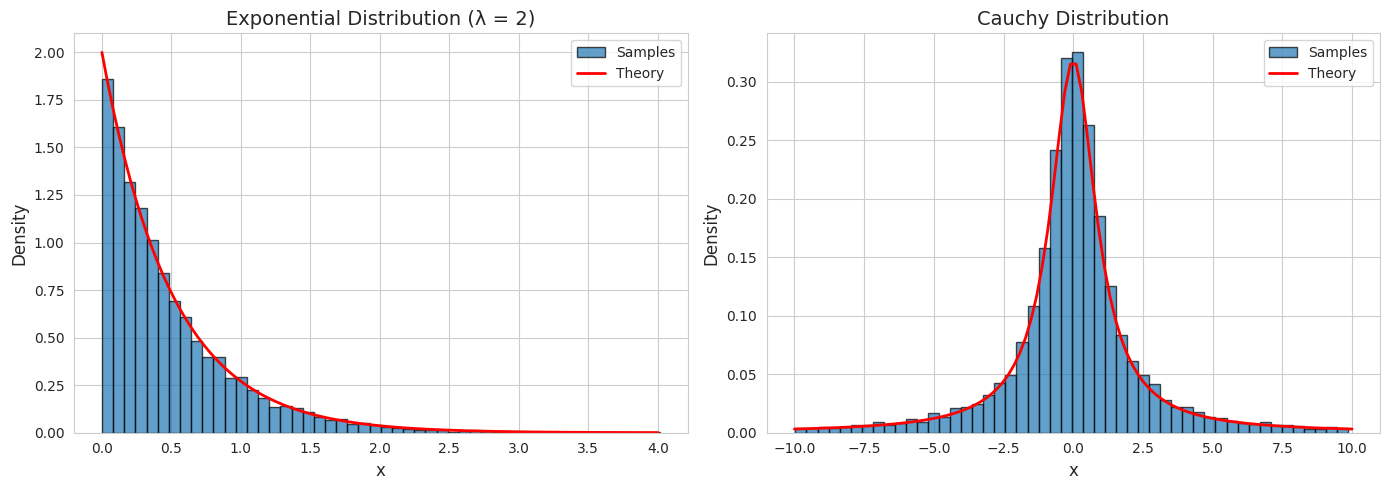

In [4]:
# Visualize inverse transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exponential
x_exp = np.linspace(0, 4, 100)
axes[0].hist(samples_exp, bins=50, density=True, alpha=0.7, edgecolor='black', label='Samples')
axes[0].plot(x_exp, lam * np.exp(-lam * x_exp), 'r-', linewidth=2, label='Theory')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'Exponential Distribution (λ = {lam})', fontsize=14)
axes[0].legend()

# Cauchy (truncated for visualization)
samples_cauchy_trunc = samples_cauchy[(samples_cauchy > -10) & (samples_cauchy < 10)]
x_cauchy = np.linspace(-10, 10, 100)
axes[1].hist(samples_cauchy_trunc, bins=50, density=True, alpha=0.7, edgecolor='black', label='Samples')
axes[1].plot(x_cauchy, stats.cauchy.pdf(x_cauchy), 'r-', linewidth=2, label='Theory')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Cauchy Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 32.3 棄却法（受理-棄却法）

### アルゴリズム
1. 提案分布 $g(x)$ から $x$ をサンプリング
2. $U \sim \text{Uniform}(0, 1)$ を生成
3. $U \leq f(x) / (M \cdot g(x))$ なら受理、そうでなければ棄却

ここで $f(x) \leq M \cdot g(x)$ for all $x$

### 受理確率
$$P(\text{accept}) = 1/M$$

In [5]:
# 棄却法
print("棄却法")
print("="*60)

# Generate Beta(2, 5) using rejection sampling with Uniform proposal
def rejection_sampling_beta(n, a=2, b=5):
    """Generate Beta random variables using rejection sampling."""
    samples = []
    n_proposed = 0
    
    # Find M (maximum of density)
    mode = (a - 1) / (a + b - 2) if a > 1 and b > 1 else 0
    M = stats.beta.pdf(mode, a, b)
    
    while len(samples) < n:
        # Propose from uniform
        x = np.random.rand()
        u = np.random.rand()
        n_proposed += 1
        
        # Accept/reject
        if u <= stats.beta.pdf(x, a, b) / M:
            samples.append(x)
    
    acceptance_rate = n / n_proposed
    return np.array(samples), acceptance_rate, M

n = 5000
a, b = 2, 5
samples_beta, acc_rate, M = rejection_sampling_beta(n, a, b)

print(f"\nBeta({a}, {b})の棄却法:")
print(f"  M (密度の最大値): {M:.4f}")
print(f"  受理率: {acc_rate:.1%} (理論値: {1/M:.1%})")
print(f"  標本平均: {np.mean(samples_beta):.4f} (理論値: {a/(a+b):.4f})")

棄却法



Beta(2, 5)の棄却法:
  M (密度の最大値): 2.4576
  受理率: 41.0% (理論値: 40.7%)
  標本平均: 0.2889 (理論値: 0.2857)


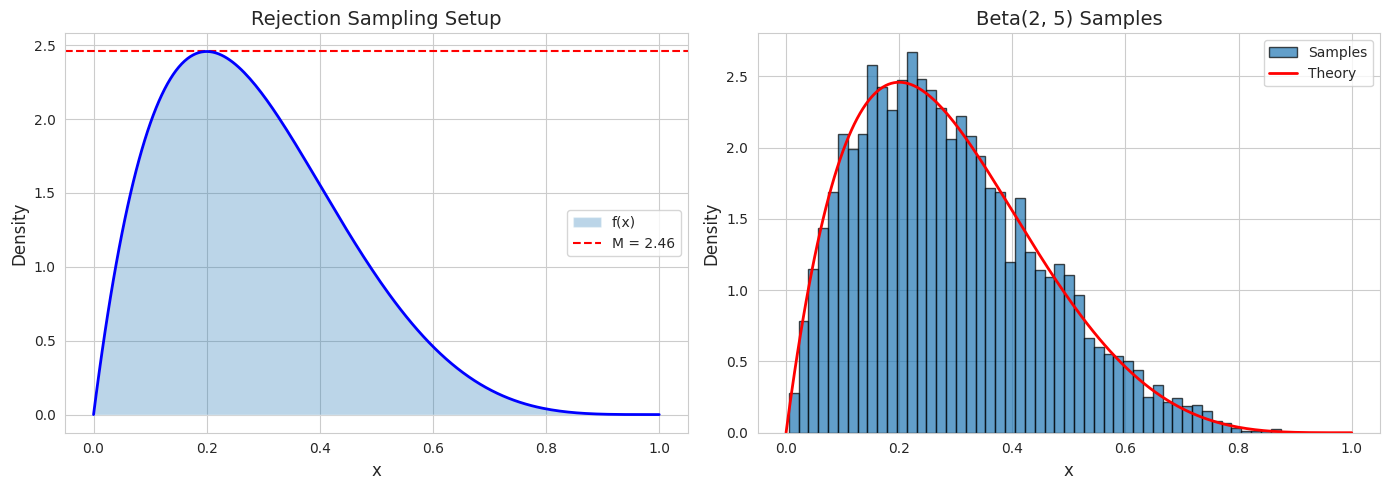

In [6]:
# Visualize rejection sampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rejection sampling illustration
x = np.linspace(0, 1, 200)
f_x = stats.beta.pdf(x, a, b)

axes[0].fill_between(x, f_x, alpha=0.3, label='f(x)')
axes[0].axhline(M, color='red', linestyle='--', label=f'M = {M:.2f}')
axes[0].plot(x, f_x, 'b-', linewidth=2)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Rejection Sampling Setup', fontsize=14)
axes[0].legend()

# Result
axes[1].hist(samples_beta, bins=50, density=True, alpha=0.7, edgecolor='black', label='Samples')
axes[1].plot(x, f_x, 'r-', linewidth=2, label='Theory')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'Beta({a}, {b}) Samples', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 32.4 モンテカルロ積分

### 基本原理
$$I = \int f(x) dx \approx \frac{1}{n} \sum_{i=1}^{n} f(X_i)$$

### 期待値の推定
$$E[g(X)] \approx \frac{1}{n} \sum_{i=1}^{n} g(X_i)$$

### 標準誤差
$$SE = \frac{s}{\sqrt{n}}$$

In [7]:
# モンテカルロ積分
print("モンテカルロ積分")
print("="*60)

# Example 1: Estimate π
# π/4 = area of quarter circle

def estimate_pi(n):
    """Estimate π using Monte Carlo integration."""
    x = np.random.rand(n)
    y = np.random.rand(n)
    inside = (x**2 + y**2) <= 1
    pi_estimate = 4 * np.mean(inside)
    se = 4 * np.std(inside) / np.sqrt(n)
    return pi_estimate, se

# Different sample sizes
sample_sizes = [100, 1000, 10000, 100000]

print(f"\n{'n':>10} {'π推定値':>12} {'SE':>10} {'誤差':>12}")
print("-"*48)

for n in sample_sizes:
    pi_est, se = estimate_pi(n)
    error = abs(pi_est - np.pi)
    print(f"{n:>10} {pi_est:>12.6f} {se:>10.6f} {error:>12.6f}")

print(f"\n真のπ: {np.pi:.6f}")

モンテカルロ積分

         n         π推定値         SE           誤差
------------------------------------------------
       100     3.200000   0.160000     0.058407
      1000     3.144000   0.051877     0.002407
     10000     3.153600   0.016338     0.012007
    100000     3.136480   0.005204     0.005113

真のπ: 3.141593


In [8]:
# Example 2: Complex integral
# ∫₀¹ exp(-x²) dx

def integrate_exp_neg_x2(n):
    """Estimate integral of exp(-x²) from 0 to 1."""
    x = np.random.rand(n)
    f_x = np.exp(-x**2)
    integral = np.mean(f_x)
    se = np.std(f_x) / np.sqrt(n)
    return integral, se

n = 100000
integral_est, se = integrate_exp_neg_x2(n)

# True value
from scipy.integrate import quad
true_integral, _ = quad(lambda x: np.exp(-x**2), 0, 1)

print(f"\n∫₀¹ exp(-x²) dx の推定:")
print(f"  MC推定値: {integral_est:.6f} ± {1.96*se:.6f}")
print(f"  真の値: {true_integral:.6f}")


∫₀¹ exp(-x²) dx の推定:
  MC推定値: 0.746951 ± 0.001245
  真の値: 0.746824


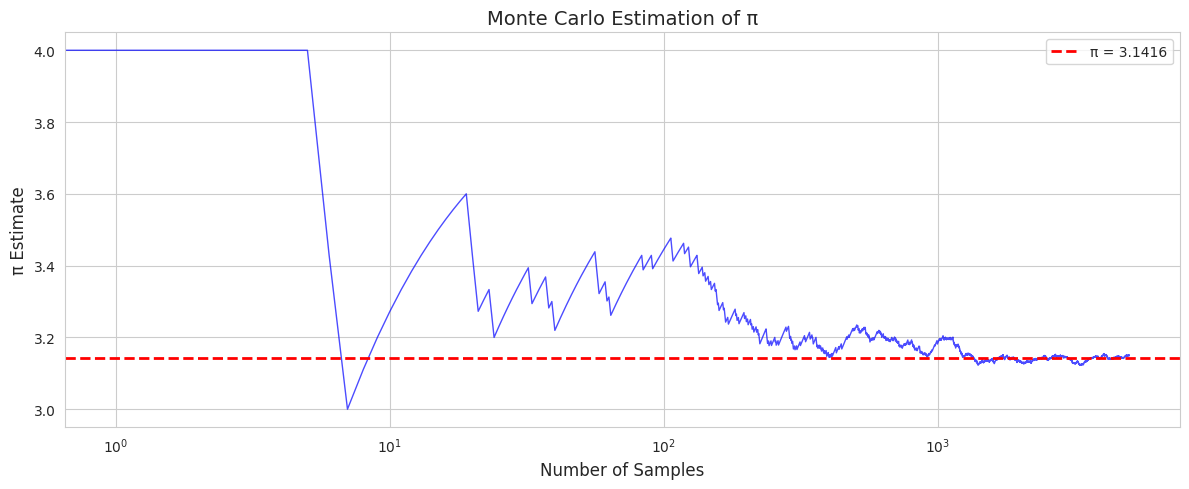

In [9]:
# Visualize convergence
np.random.seed(123)

n_max = 5000
x = np.random.rand(n_max)
y = np.random.rand(n_max)
inside = (x**2 + y**2) <= 1

# Cumulative estimate
cumsum = np.cumsum(inside)
estimates = 4 * cumsum / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(estimates, 'b-', linewidth=1, alpha=0.7)
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label=f'π = {np.pi:.4f}')
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('π Estimate', fontsize=12)
ax.set_title('Monte Carlo Estimation of π', fontsize=14)
ax.legend()
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 32.5 ブートストラップ法

### 基本手順
1. 元データから復元抽出してブートストラップ標本を作成
2. 統計量を計算
3. 1-2をB回繰り返す
4. 標準誤差や信頼区間を構成

### 信頼区間
- パーセンタイル法
- BCa法（バイアス補正・加速）

In [10]:
# ブートストラップ法
print("ブートストラップ法")
print("="*60)

# Sample data
np.random.seed(456)
n = 50
data = np.random.exponential(scale=2, size=n)

# Bootstrap for mean
B = 10000
boot_means = []

for _ in range(B):
    boot_sample = np.random.choice(data, size=n, replace=True)
    boot_means.append(np.mean(boot_sample))

boot_means = np.array(boot_means)

# Results
print(f"\n元データの標本平均: {np.mean(data):.4f}")
print(f"\nブートストラップ推定:")
print(f"  平均: {np.mean(boot_means):.4f}")
print(f"  標準誤差: {np.std(boot_means):.4f}")

# Confidence interval (percentile method)
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)
print(f"  95% CI (パーセンタイル法): [{ci_lower:.4f}, {ci_upper:.4f}]")

# Compare with normal theory
se_theory = np.std(data) / np.sqrt(n)
print(f"\n正規理論による標準誤差: {se_theory:.4f}")

ブートストラップ法

元データの標本平均: 1.7108

ブートストラップ推定:
  平均: 1.7081
  標準誤差: 0.2156
  95% CI (パーセンタイル法): [1.3054, 2.1506]

正規理論による標準誤差: 0.2170


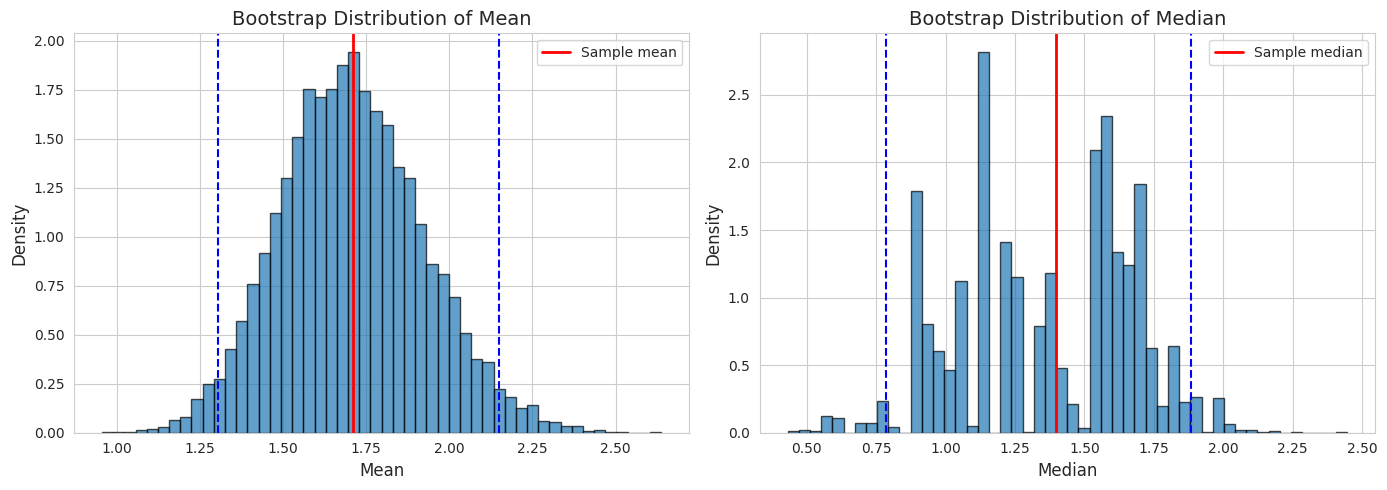

In [11]:
# Bootstrap for median
boot_medians = []
for _ in range(B):
    boot_sample = np.random.choice(data, size=n, replace=True)
    boot_medians.append(np.median(boot_sample))

boot_medians = np.array(boot_medians)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bootstrap distribution of mean
axes[0].hist(boot_means, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(data), color='red', linestyle='-', linewidth=2, label='Sample mean')
axes[0].axvline(ci_lower, color='blue', linestyle='--', linewidth=1.5)
axes[0].axvline(ci_upper, color='blue', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Mean', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Bootstrap Distribution of Mean', fontsize=14)
axes[0].legend()

# Bootstrap distribution of median
axes[1].hist(boot_medians, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[1].axvline(np.median(data), color='red', linestyle='-', linewidth=2, label='Sample median')
ci_med_lower = np.percentile(boot_medians, 2.5)
ci_med_upper = np.percentile(boot_medians, 97.5)
axes[1].axvline(ci_med_lower, color='blue', linestyle='--', linewidth=1.5)
axes[1].axvline(ci_med_upper, color='blue', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Median', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Bootstrap Distribution of Median', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 32.6 MCMC入門

### Metropolis-Hastingsアルゴリズム
1. 提案分布 $q(x' | x)$ から候補 $x'$ を生成
2. 受理確率を計算:
$$\alpha = \min\left(1, \frac{p(x') q(x | x')}{p(x) q(x' | x)}\right)$$
3. 確率 $\alpha$ で受理、そうでなければ現在の状態を維持

### ギブスサンプリング
各変数を条件付き分布から順次サンプリング

In [12]:
# Metropolis-Hastingsアルゴリズム
print("MCMC: Metropolis-Hastings")
print("="*60)

# Target: mixture of two normals
def target_density(x):
    return 0.3 * stats.norm.pdf(x, -2, 1) + 0.7 * stats.norm.pdf(x, 2, 1)

def metropolis_hastings(n_samples, initial=0, proposal_sd=2):
    """Metropolis-Hastings with Gaussian proposal."""
    samples = [initial]
    current = initial
    n_accepted = 0
    
    for _ in range(n_samples - 1):
        # Propose
        proposal = current + np.random.normal(0, proposal_sd)
        
        # Acceptance probability
        alpha = min(1, target_density(proposal) / target_density(current))
        
        # Accept/reject
        if np.random.rand() < alpha:
            current = proposal
            n_accepted += 1
        
        samples.append(current)
    
    acceptance_rate = n_accepted / (n_samples - 1)
    return np.array(samples), acceptance_rate

# Run MCMC
n_samples = 10000
samples_mh, acc_rate_mh = metropolis_hastings(n_samples, proposal_sd=2)

print(f"\nサンプル数: {n_samples}")
print(f"受理率: {acc_rate_mh:.1%}")

MCMC: Metropolis-Hastings



サンプル数: 10000
受理率: 60.0%


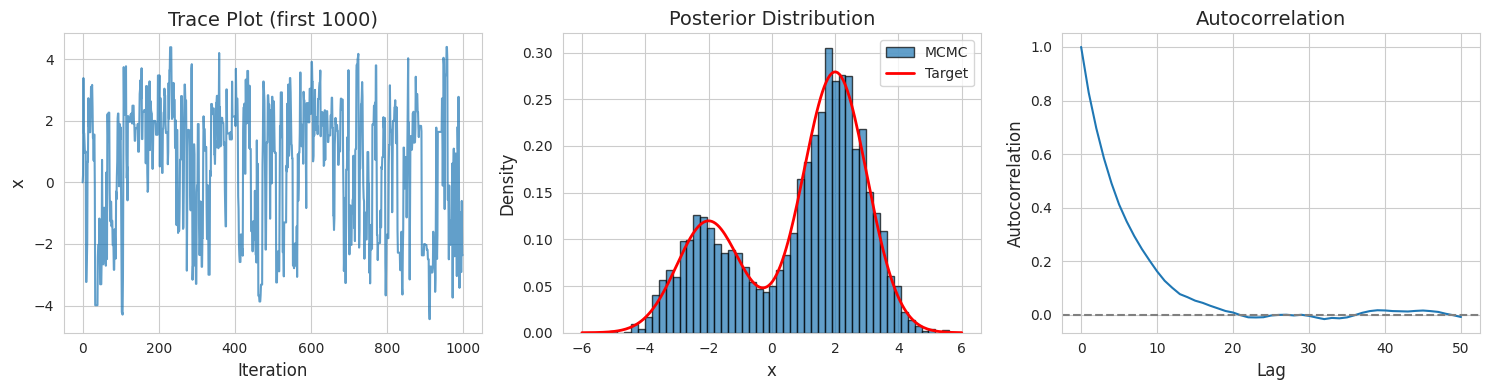

In [13]:
# Visualize MCMC results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Trace plot
axes[0].plot(samples_mh[:1000], alpha=0.7)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('x', fontsize=12)
axes[0].set_title('Trace Plot (first 1000)', fontsize=14)

# Histogram vs target
x_range = np.linspace(-6, 6, 200)
# Discard burn-in
burn_in = 1000
axes[1].hist(samples_mh[burn_in:], bins=50, density=True, alpha=0.7, edgecolor='black', label='MCMC')
axes[1].plot(x_range, target_density(x_range), 'r-', linewidth=2, label='Target')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Posterior Distribution', fontsize=14)
axes[1].legend()

# Autocorrelation
from statsmodels.tsa.stattools import acf
acf_values = acf(samples_mh[burn_in:], nlags=50)
axes[2].plot(acf_values)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('Lag', fontsize=12)
axes[2].set_ylabel('Autocorrelation', fontsize=12)
axes[2].set_title('Autocorrelation', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
# ギブスサンプリング
print("\nMCMC: ギブスサンプリング")
print("="*60)

# Target: Bivariate normal with correlation
def gibbs_sampling_bivariate(n_samples, mu1=0, mu2=0, sigma1=1, sigma2=1, rho=0.8):
    """Gibbs sampling for bivariate normal."""
    samples = np.zeros((n_samples, 2))
    x1, x2 = 0, 0
    
    for i in range(n_samples):
        # Sample x1 | x2
        cond_mean1 = mu1 + rho * (sigma1 / sigma2) * (x2 - mu2)
        cond_sd1 = sigma1 * np.sqrt(1 - rho**2)
        x1 = np.random.normal(cond_mean1, cond_sd1)
        
        # Sample x2 | x1
        cond_mean2 = mu2 + rho * (sigma2 / sigma1) * (x1 - mu1)
        cond_sd2 = sigma2 * np.sqrt(1 - rho**2)
        x2 = np.random.normal(cond_mean2, cond_sd2)
        
        samples[i] = [x1, x2]
    
    return samples

# Run Gibbs
rho = 0.8
samples_gibbs = gibbs_sampling_bivariate(5000, rho=rho)

print(f"\n相関係数 ρ = {rho}")
print(f"標本相関: {np.corrcoef(samples_gibbs[500:, 0], samples_gibbs[500:, 1])[0, 1]:.4f}")


MCMC: ギブスサンプリング

相関係数 ρ = 0.8
標本相関: 0.7940


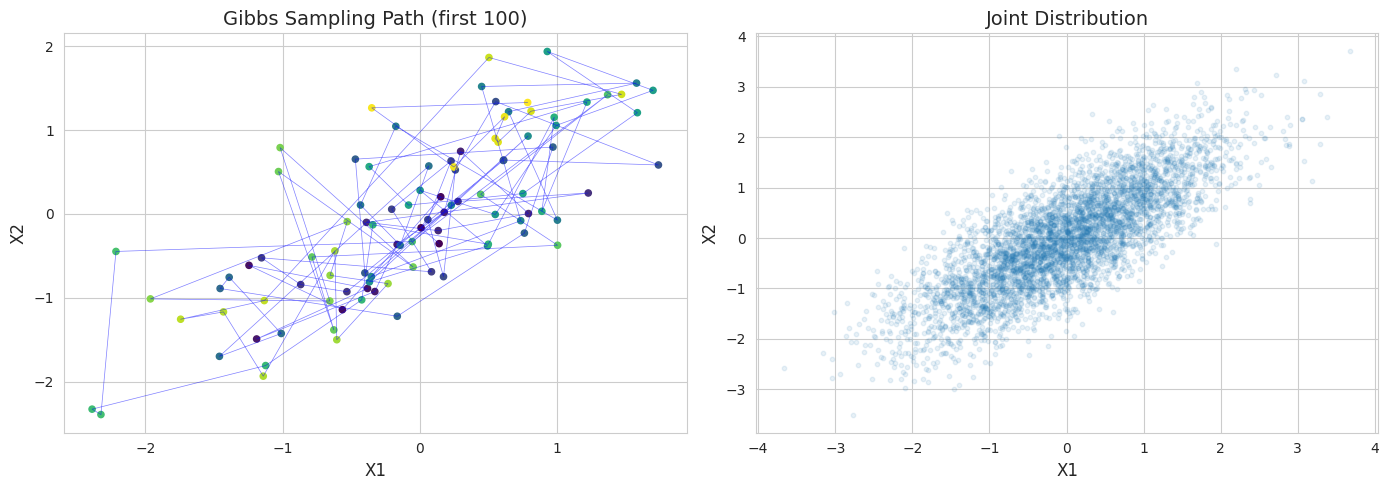

In [15]:
# Visualize Gibbs sampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trace (path)
axes[0].plot(samples_gibbs[:100, 0], samples_gibbs[:100, 1], 'b-', alpha=0.5, linewidth=0.5)
axes[0].scatter(samples_gibbs[:100, 0], samples_gibbs[:100, 1], c=range(100), cmap='viridis', s=20)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('Gibbs Sampling Path (first 100)', fontsize=14)

# Joint distribution
burn_in = 500
axes[1].scatter(samples_gibbs[burn_in:, 0], samples_gibbs[burn_in:, 1], alpha=0.1, s=10)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('Joint Distribution', fontsize=14)

plt.tight_layout()
plt.show()

## 32.7 練習問題

### 問題1
逆変換法が使えない場合の例を1つ挙げ、その理由を説明せよ。

### 問題2
棄却法でMを小さくすることの利点と難しさを説明せよ。

### 問題3
MCMCの「バーンイン期間」とは何か、なぜ必要か。

In [16]:
# 問題1の解答
print("問題1: 逆変換法が使えない場合")
print("="*60)

print("""
【例: 正規分布】
F(x) = ∫_{-∞}^x (1/√(2π)) exp(-t²/2) dt

【使えない理由】
1. 累積分布関数が解析的に計算できない
   - 誤差関数erf(x)を含む
   - 閉じた形の逆関数が存在しない

2. 数値的な逆関数の計算が必要
   - 各サンプルで求根計算
   - 計算コストが高い

【代替手法】
・Box-Muller法
・極座標法
・Ziggurat法
""")

問題1: 逆変換法が使えない場合

【例: 正規分布】
F(x) = ∫_{-∞}^x (1/√(2π)) exp(-t²/2) dt

【使えない理由】
1. 累積分布関数が解析的に計算できない
   - 誤差関数erf(x)を含む
   - 閉じた形の逆関数が存在しない

2. 数値的な逆関数の計算が必要
   - 各サンプルで求根計算
   - 計算コストが高い

【代替手法】
・Box-Muller法
・極座標法
・Ziggurat法



In [17]:
# 問題2の解答
print("問題2: 棄却法のM")
print("="*60)

print("""
【Mを小さくする利点】
受理確率 = 1/M
→ Mが小さいほど効率的
→ 生成する候補点が少なくて済む

【難しさ】
1. f(x) ≤ M·g(x) を満たす必要
   - すべてのxで成り立つ必要
   - f/g の最大値を見つける必要

2. 最適な提案分布gの選択
   - fに形が近いほどMが小さくなる
   - しかしgからサンプリングできる必要

3. トレードオフ
   - 複雑なg → 小さいM、サンプリングが困難
   - 単純なg → 大きいM、効率が悪い

【実用的なアプローチ】
・適応的棄却サンプリング
・重点サンプリング
""")

問題2: 棄却法のM

【Mを小さくする利点】
受理確率 = 1/M
→ Mが小さいほど効率的
→ 生成する候補点が少なくて済む

【難しさ】
1. f(x) ≤ M·g(x) を満たす必要
   - すべてのxで成り立つ必要
   - f/g の最大値を見つける必要

2. 最適な提案分布gの選択
   - fに形が近いほどMが小さくなる
   - しかしgからサンプリングできる必要

3. トレードオフ
   - 複雑なg → 小さいM、サンプリングが困難
   - 単純なg → 大きいM、効率が悪い

【実用的なアプローチ】
・適応的棄却サンプリング
・重点サンプリング



In [18]:
# 問題3の解答
print("問題3: バーンイン期間")
print("="*60)

print("""
【バーンイン期間とは】
MCMCの初期サンプルを捨てる期間

【なぜ必要か】
1. 初期状態への依存
   - 初期値は目標分布から離れている可能性
   - チェーンが定常分布に収束するまで時間がかかる

2. 収束の保証
   - 理論的には無限に長いチェーンで定常分布に収束
   - 有限では初期バイアスが残る

3. 推定のバイアス低減
   - バーンイン後のサンプルのみを使用
   - より正確な事後分布の推定

【決め方】
・トレースプロットで視覚的に判断
・複数チェーンの比較（Gelman-Rubin統計量）
・通常は全体の10-50%
""")

問題3: バーンイン期間

【バーンイン期間とは】
MCMCの初期サンプルを捨てる期間

【なぜ必要か】
1. 初期状態への依存
   - 初期値は目標分布から離れている可能性
   - チェーンが定常分布に収束するまで時間がかかる

2. 収束の保証
   - 理論的には無限に長いチェーンで定常分布に収束
   - 有限では初期バイアスが残る

3. 推定のバイアス低減
   - バーンイン後のサンプルのみを使用
   - より正確な事後分布の推定

【決め方】
・トレースプロットで視覚的に判断
・複数チェーンの比較（Gelman-Rubin統計量）
・通常は全体の10-50%



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---